In [1]:
import torchvision.transforms as T

transform = T.Compose([
    T.ToPILImage(),          # convert the raw (84, 84, 3) NumPy array into a PIL Image
    T.ToTensor(),            # convert PIL Image -> PyTorch tensor, shape becomes (3, 84, 84), values scaled to [0, 1]
    T.Normalize(
        mean=[0.485, 0.456, 0.406],   # standard ImageNet channel means
        std=[0.229, 0.224, 0.225]     # standard ImageNet channel stds
    ),
])

In [2]:
!pip install --upgrade kaggle -q

In [3]:
import os
os.environ["KAGGLE_API_TOKEN"] = "KAGGLE_API_TOKEN"

In [4]:
!kaggle datasets download -d whitemoon/miniimagenet -p /content/data --unzip
!ls /content/data

Dataset URL: https://www.kaggle.com/datasets/whitemoon/miniimagenet
License(s): unknown
Resuming from 252706816 bytes (820959585 bytes left)...
100% 1.00G/1.00G [00:50<00:00, 16.3MB/s]

mini-imagenet-cache-test.pkl   mini-imagenet-cache-val.pkl
mini-imagenet-cache-train.pkl


In [5]:
!git clone https://github.com/BhoomiJindal/few-shot-meta-learning.git /content/repo
import sys
sys.path.append("/content/repo")

fatal: destination path '/content/repo' already exists and is not an empty directory.


In [6]:
from src.data.miniimagenet import MiniImageNet

train_dataset = MiniImageNet("/content/data/mini-imagenet-cache-train.pkl", transform=transform)
val_dataset   = MiniImageNet("/content/data/mini-imagenet-cache-val.pkl", transform=transform)
test_dataset  = MiniImageNet("/content/data/mini-imagenet-cache-test.pkl", transform=transform)

print("Train: ", len(train_dataset), "images,", train_dataset.num_classes, "classes")
print("Val:   ", len(val_dataset), "images,", val_dataset.num_classes, "classes")
print("Test:  ", len(test_dataset), "images,", test_dataset.num_classes, "classes")

Train:  38400 images, 64 classes
Val:    9600 images, 16 classes
Test:   12000 images, 20 classes


In [9]:
import numpy as np

def tensor_to_image(tensor):
    """
    Converts a normalized (3, 84, 84) PyTorch tensor back into a displayable
    (84, 84, 3) NumPy array in the 0-1 range, by reversing the Normalize step
    and reordering dimensions back to height-width-channels.
    """
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = tensor.numpy().transpose(1, 2, 0)   # (3, 84, 84) -> (84, 84, 3)
    img = img * std + mean                     # reverse the normalization
    img = np.clip(img, 0, 1)                   # guard against tiny float overshoot
    return img

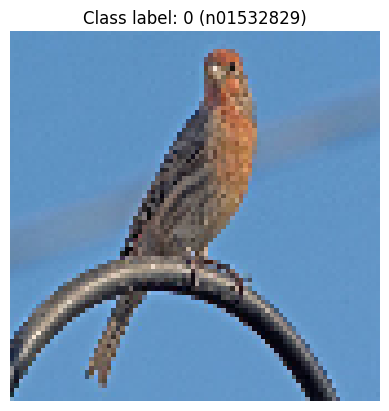

In [12]:
import matplotlib.pyplot as plt

img, label = train_dataset[0]
plt.imshow(tensor_to_image(img))
plt.title(f"Class label: {label} ({train_dataset.class_names[label]})")
plt.axis("off")
plt.show()

In [7]:
!cd /content/repo && git pull

Already up to date.


In [8]:
from src.data.episodic_sampler import EpisodicSampler

sampler = EpisodicSampler(train_dataset, n_way=5, k_shot=5, q_query=15, seed=42)
support_images, support_labels, query_images, query_labels = sampler.sample_episode()

print("support_images:", support_images.shape)
print("support_labels:", support_labels.shape, support_labels)
print("query_images:", query_images.shape)
print("query_labels:", query_labels.shape)

support_images: torch.Size([25, 3, 84, 84])
support_labels: torch.Size([25]) tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
        4])
query_images: torch.Size([75, 3, 84, 84])
query_labels: torch.Size([75])


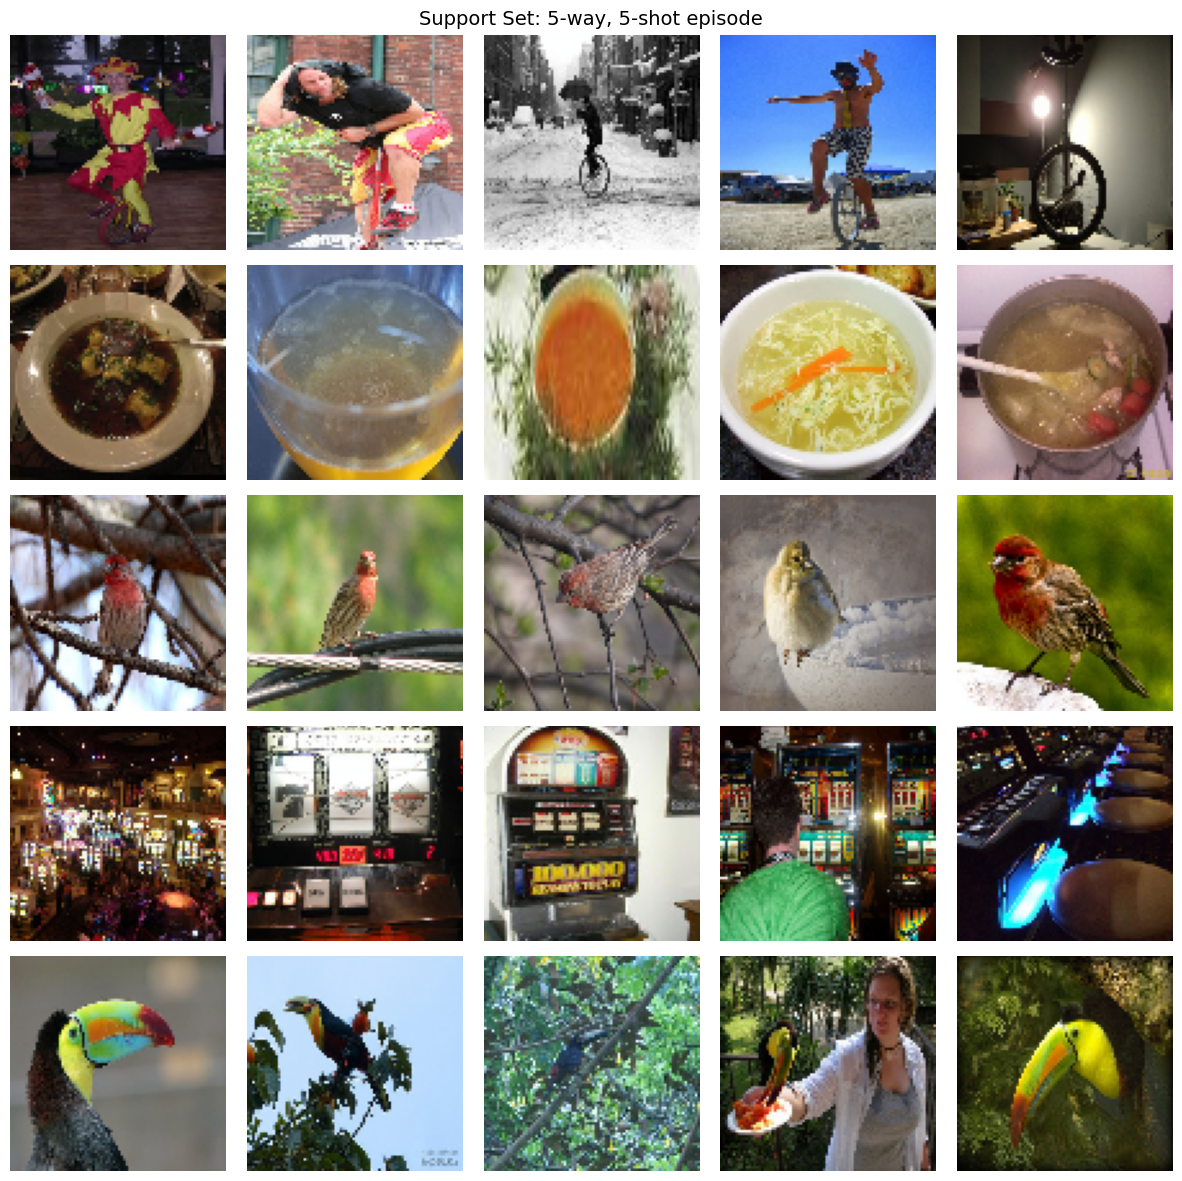

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(sampler.n_way, sampler.k_shot, figsize=(12, 12))

for class_idx in range(sampler.n_way):
    for shot_idx in range(sampler.k_shot):
        flat_idx = class_idx * sampler.k_shot + shot_idx
        img = support_images[flat_idx]
        axes[class_idx, shot_idx].imshow(tensor_to_image(img))
        axes[class_idx, shot_idx].axis("off")
        if shot_idx == 0:
            axes[class_idx, shot_idx].set_ylabel(f"Class {class_idx}", fontsize=12)

plt.suptitle("Support Set: 5-way, 5-shot episode", fontsize=14)
plt.tight_layout()
plt.show()

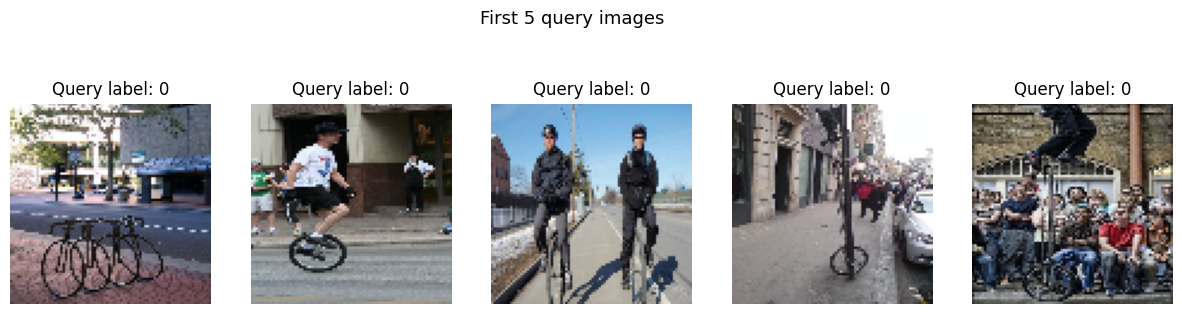

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(tensor_to_image(query_images[i]))
    axes[i].set_title(f"Query label: {query_labels[i].item()}")
    axes[i].axis("off")
plt.suptitle("First 5 query images", fontsize=13)
plt.show()